<a href="https://colab.research.google.com/github/kwanda2426/ACML_26_P1/blob/main/ACML_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Preprocessing

In [1]:
!pip -q install plotly scikit-learn tabulate pandas gdown scorecardpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# Libraries for data loading, data manipulation and data visulisation
import numpy as np
import pandas as pd

import gdown

import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import plotly.express as px
from scipy.stats import kurtosis

import scorecardpy as sc


#Feature engineering, selection and Model training
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
from tabulate import tabulate
from IPython.display import display

In [3]:
# Reading and downloading from drive
file_id = "1deTfwvspgT545M_-ZCkHU4RqQl_b1jzp"
url = f"https://drive.google.com/uc?id={file_id}"

output = "data.csv"
gdown.download(url, output, quiet = False)

Downloading...
From (original): https://drive.google.com/uc?id=1deTfwvspgT545M_-ZCkHU4RqQl_b1jzp
From (redirected): https://drive.google.com/uc?id=1deTfwvspgT545M_-ZCkHU4RqQl_b1jzp&confirm=t&uuid=f144e218-19fb-4941-8b41-165aa0442d78
To: /content/data.csv
100%|██████████| 166M/166M [00:04<00:00, 40.7MB/s]


'data.csv'

In [4]:
# reading into a dataframe
df = pd.read_csv(output)
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [5]:
# Remove ID Columns
df = df.drop(columns=['SK_ID_CURR'])

print(df.shape)

(307511, 121)


In [6]:
df.TARGET.value_counts()

,count
TARGET,
0,282686
1,24825


In [7]:
# Check Columns With Only One Value

low_variance = []

for col in df.columns:
    if df[col].nunique() <= 1:
        low_variance.append(col)

print(low_variance)

df = df.drop(columns=low_variance)

print(df.shape)

[]
(307511, 121)


In [8]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

In [9]:
#Imputation - skip
# Fill numerical missing values column by column using median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values column by column using mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values remaining:")
print(df.isnull().sum().sum())

Missing values remaining:
0


In [10]:
# Changing column names
df.columns = df.columns.str.replace(' ', '_', regex=False).str.lower()

cols = ['code_gender'] #+ [i for i in df.columns if '_medi' in i] + [i for i in df.columns if '_mod' in i]

df_final = df.drop(cols, axis = 1)

In [11]:
df_final.head()

,target,name_contract_type,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,region_population_relative,days_birth,days_employed,days_registration,days_id_publish,own_car_age,flag_mobil,flag_emp_phone,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,occupation_type,cnt_fam_members,region_rating_client,region_rating_client_w_city,weekday_appr_process_start,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,organization_type,ext_source_1,ext_source_2,ext_source_3,apartments_avg,basementarea_avg,years_beginexpluatation_avg,years_build_avg,commonarea_avg,elevators_avg,entrances_avg,floorsmax_avg,floorsmin_avg,landarea_avg,livingapartments_avg,livingarea_avg,nonlivingapartments_avg,nonlivingarea_avg,apartments_mode,basementarea_mode,years_beginexpluatation_mode,years_build_mode,commonarea_mode,elevators_mode,entrances_mode,floorsmax_mode,floorsmin_mode,landarea_mode,livingapartments_mode,livingarea_mode,nonlivingapartments_mode,nonlivingarea_mode,apartments_medi,basementarea_medi,years_beginexpluatation_medi,years_build_medi,commonarea_medi,elevators_medi,entrances_medi,floorsmax_medi,floorsmin_medi,landarea_medi,livingapartments_medi,livingarea_medi,nonlivingapartments_medi,nonlivingarea_medi,fondkapremont_mode,housetype_mode,totalarea_mode,wallsmaterial_mode,emergencystate_mode,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,days_last_phone_change,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,1,Cash loans,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,9.0,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,9.0,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,0.535276,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.505998,0.555912,0.729567,0.0876,0.0763,0.9816,0.7552,0.0211,0.00,0.1379,0.1667,0.2083,0.0481,0.0756,0.0745,0.0000,0.0036,0.0840,0.0746,0.9816,0.7648,0.0190,0.0000,0.1379,0.1667,

In [12]:
df_final.shape

(307511, 120)

In [13]:
df_final.to_csv('df_final.csv', index=False)

# Data Split

In [14]:
df = df_final.copy()

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    stratify = y,
    random_state = 42
)

In [15]:
train = X_train.copy()
train['target'] = y_train

test = X_test.copy()
test['target'] = y_test

In [16]:
%%time
bins = sc.woebin(train, y = 'target' ,print_step = 0, check_cate_num=False)

[INFO] creating woe binning ...
Binning on 215257 rows and 120 columns in 00:02:08
CPU times: user 2min 3s, sys: 2.49 s, total: 2min 5s
Wall time: 2min 8s


In [17]:
train_woe = sc.woebin_ply(train, bins)

test_woe = sc.woebin_ply(test, bins)

[INFO] converting into woe values ...
Woe transformating on 215257 rows and 119 columns in 00:01:21
[INFO] converting into woe values ...
Woe transformating on 92254 rows and 119 columns in 00:00:37


In [18]:
features = [c for c in train_woe.columns if c != 'target']

X_train_woe = train_woe[features]
y_train_woe = train_woe['target']

X_test_woe = test_woe[features]
y_test_woe = test_woe['target']

# Training the Model logistic regression

In [19]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# Initialize model
lr = LogisticRegression(max_iter = 1000)

# Cross-validation evaluation
cv_scores = cross_val_score(
    lr,
    X_train_woe,
    y_train_woe,
    cv = 5,
    scoring = 'roc_auc'
)

print("Mean CV ROC AUC:", cv_scores.mean())

# Train final model on full training data
lr.fit(X_train_woe, y_train_woe)

Mean CV ROC AUC: 0.7383450254214825


LogisticRegression(max_iter=1000)

In [20]:
lr_pred_proba = lr.predict_proba(X_test_woe)[:,1]

In [21]:
lr_pred = (lr_pred_proba >= 0.5).astype(int)

In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_woe, lr_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9191471372515013


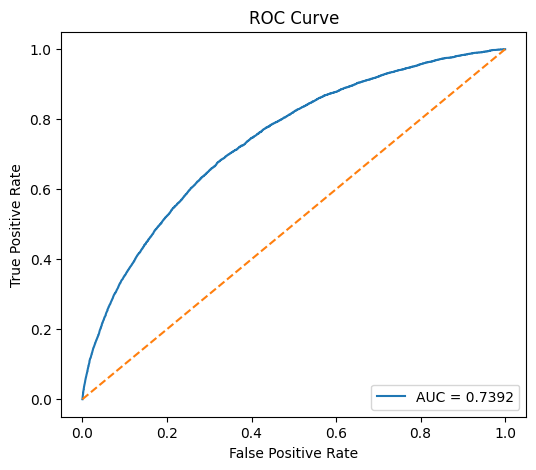

In [23]:
# Calculate ROC curve
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities
y_prob = lr.predict_proba(X_test_woe)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_woe, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test_woe, y_prob)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.show()

# Tune logistic regression

In [24]:
# Model
log_reg = LogisticRegression()

# Hyperparameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1],
    'penalty': ['l2'],
    'solver': ['liblinear','saga'],
    'class_weight': [None, 'balanced'],
    'max_iter': [100, 500]
}

# Grid Search
grid_search = GridSearchCV(
    estimator = log_reg,
    param_grid = param_grid,
    cv = 3,
    scoring = 'roc_auc',   # good for credit/risk models
    n_jobs = -1,
    verbose = 1
)

# Fit
grid_search.fit(X_train_woe, y_train_woe)


Fitting 3 folds for each of 32 candidates, totalling 96 fits


GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1],
                         'class_weight': [None, 'balanced'],
                         'max_iter': [100, 500], 'penalty': ['l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='roc_auc', verbose=1)

In [25]:
# Best model
best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'C': 0.1, 'class_weight': None, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}

Best CV ROC-AUC:
0.7384571533610963


###Re Evaluate on Test set

In [26]:
# Predictions
from sklearn.metrics import classification_report
y_pred = best_model.predict(X_test_woe)
y_prob = best_model.predict_proba(X_test_woe)[:, 1]

# Metrics
print(classification_report(y_test_woe, y_pred))

print("Test ROC-AUC:",
      roc_auc_score(y_test_woe, y_prob))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     84806
           1       0.46      0.00      0.01      7448

    accuracy                           0.92     92254
   macro avg       0.69      0.50      0.48     92254
weighted avg       0.88      0.92      0.88     92254

Test ROC-AUC: 0.7392528468906086


# Train Model stacking model

In [27]:
df.head()

,target,name_contract_type,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,region_population_relative,days_birth,days_employed,days_registration,days_id_publish,own_car_age,flag_mobil,flag_emp_phone,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,occupation_type,cnt_fam_members,region_rating_client,region_rating_client_w_city,weekday_appr_process_start,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,organization_type,ext_source_1,ext_source_2,ext_source_3,apartments_avg,basementarea_avg,years_beginexpluatation_avg,years_build_avg,commonarea_avg,elevators_avg,entrances_avg,floorsmax_avg,floorsmin_avg,landarea_avg,livingapartments_avg,livingarea_avg,nonlivingapartments_avg,nonlivingarea_avg,apartments_mode,basementarea_mode,years_beginexpluatation_mode,years_build_mode,commonarea_mode,elevators_mode,entrances_mode,floorsmax_mode,floorsmin_mode,landarea_mode,livingapartments_mode,livingarea_mode,nonlivingapartments_mode,nonlivingarea_mode,apartments_medi,basementarea_medi,years_beginexpluatation_medi,years_build_medi,commonarea_medi,elevators_medi,entrances_medi,floorsmax_medi,floorsmin_medi,landarea_medi,livingapartments_medi,livingarea_medi,nonlivingapartments_medi,nonlivingarea_medi,fondkapremont_mode,housetype_mode,totalarea_mode,wallsmaterial_mode,emergencystate_mode,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,days_last_phone_change,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,1,Cash loans,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,9.0,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,Cash loans,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,9.0,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,0.535276,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,Revolving loans,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.505998,0.555912,0.729567,0.0876,0.0763,0.9816,0.7552,0.0211,0.00,0.1379,0.1667,0.2083,0.0481,0.0756,0.0745,0.0000,0.0036,0.0840,0.0746,0.9816,0.7648,0.0190,0.0000,0.1379,0.1667,

In [28]:
X = df.drop('target', axis=1)
y = df['target']



In [29]:
df.shape

(307511, 120)

In [30]:
categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

print(f"Categorical: {len(categorical_cols)}")
print(f"Numeric: {len(numeric_cols)}")

Categorical: 15
Numeric: 104


# Data Split

In [31]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size = 0.30,
    stratify = y,
    random_state = 42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size = 0.50,
    stratify = y_temp,
    random_state = 42
)

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Preprocessing Cat features

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [34]:
!pip -q install xgboost

# Modelling

In [35]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    classification_report
)

In [36]:
xgb_model = XGBClassifier(
    n_estimators = 500,
    max_depth = 6,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    objective = "binary:logistic",
    eval_metric = "auc",
    random_state = 42,
    tree_method = "hist"
)

In [37]:
xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", xgb_model)
])

In [38]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['name_contract_type',
                                                   'flag_own_car',
                                                   'flag_own_realty',
                                                   'name_type_suite',
                                                   'name_income_type',
                                                   'name_education_type',
                                                   'name_family_status',
                                                   'name_housing_type',
                                                   'occupation_type',
                                                   'weekday_appr_process_start',
                                                   'organization_type',
                                                   'f...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=None,
                               num_parallel_tree=None, ...))])

# Evaluate XGBoost

In [39]:
valid_probs = xgb_pipeline.predict_proba(X_valid)[:, 1]

In [40]:
auc = roc_auc_score(y_valid, valid_probs)

print("Validation ROC-AUC:", auc)

Validation ROC-AUC: 0.7560820592031454


In [41]:
valid_preds = (valid_probs >= 0.5).astype(int)

print(classification_report(y_valid, valid_preds))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     42403
           1       0.58      0.02      0.05      3724

    accuracy                           0.92     46127
   macro avg       0.75      0.51      0.50     46127
weighted avg       0.89      0.92      0.88     46127



# Retrain XGBoost

In [42]:
negatives = (y_train == 0).sum()
positives = (y_train == 1).sum()

scale_pos_weight = negatives / positives
print(scale_pos_weight)

11.38746619094205


In [43]:
xgb_model = XGBClassifier(
    n_estimators=700,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    tree_method="hist",
    reg_alpha=1,
    reg_lambda=1
)

In [44]:
xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", xgb_model)
])

xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['name_contract_type',
                                                   'flag_own_car',
                                                   'flag_own_realty',
                                                   'name_type_suite',
                                                   'name_income_type',
                                                   'name_education_type',
                                                   'name_family_status',
                                                   'name_housing_type',
                                                   'occupation_type',
                                                   'weekday_appr_process_start',
                                                   'organization_type',
                                                   'f...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=700, n_jobs=None,
                               num_parallel_tree=None, ...))])

# Re Evaluate

In [45]:
valid_probs = xgb_pipeline.predict_proba(X_valid)[:, 1]

auc = roc_auc_score(y_valid, valid_probs)

print("Validation ROC-AUC:", auc)

Validation ROC-AUC: 0.7540577923055471


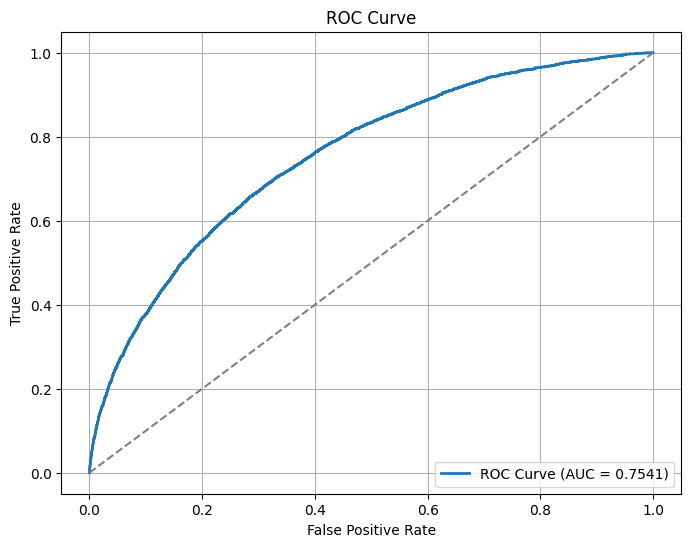

In [46]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_valid, valid_probs)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', linewidth=2)

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.grid(True)
plt.show()

In [47]:
trained_xgb = xgb_pipeline.named_steps["model"]

In [48]:
encoded_cat_features = (
    xgb_pipeline.named_steps["prep"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_cols)
)

all_features = np.concatenate([
    encoded_cat_features,
    numeric_cols
])

In [49]:
importance_df = pd.DataFrame({
    "feature": all_features,
    "importance": trained_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

In [50]:
importance_df.head(20)

,feature,importance
165,ext_source_2,0.024315
166,ext_source_3,0.024078
22,name_education_type_Higher education,0.018930
120,organization_type_XNA,0.011967
216,flag_document_3,0.011088
164,ext_source_1,0.011060
20,name_income_type_Working,0.011022
16,name_income_type_Pensioner,0.009644
1,name_contract_type_Revolving loans,0.008986
0,name_contract_type_Cash loans,0.008939


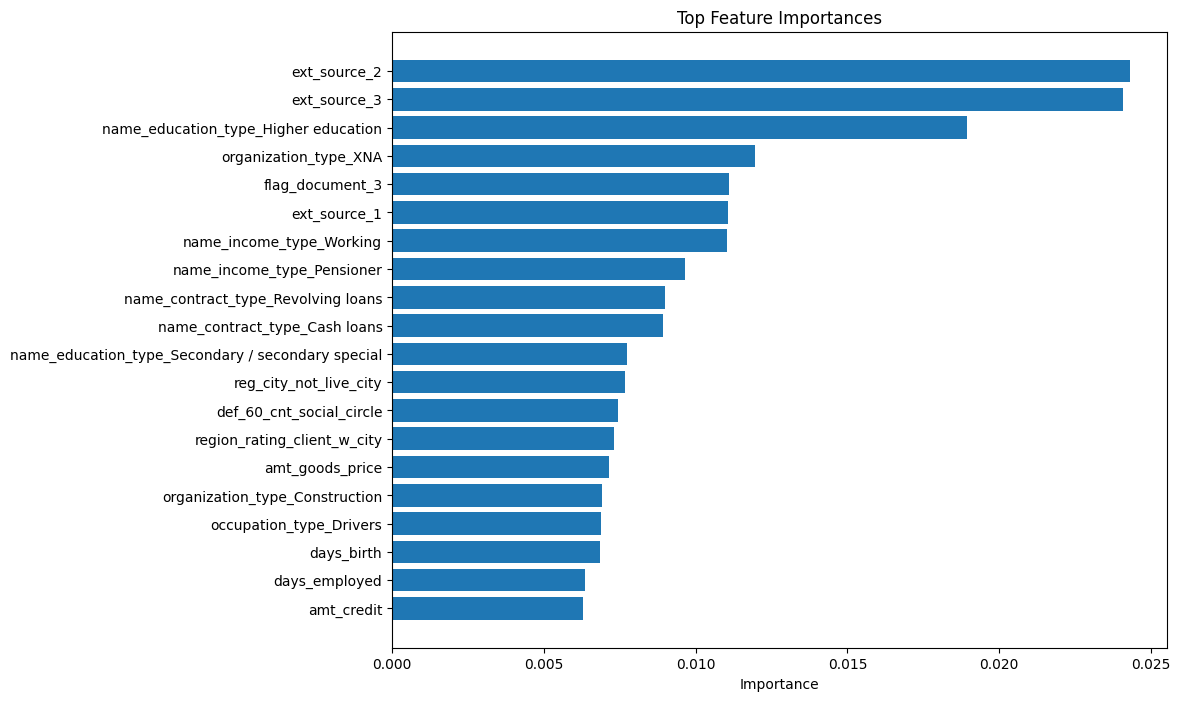

In [51]:
import matplotlib.pyplot as plt

top_n = 20

plt.figure(figsize=(10, 8))

plt.barh(
    importance_df.head(top_n)["feature"][::-1],
    importance_df.head(top_n)["importance"][::-1]
)

plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.show()

In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Create NN preprocessor

In [53]:
nn_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            numeric_cols
        )
    ]
)

# Fit + transform

In [54]:
X_train_nn = nn_preprocessor.fit_transform(X_train)

X_valid_nn = nn_preprocessor.transform(X_valid)

X_test_nn = nn_preprocessor.transform(X_test)

In [55]:
type(X_train_nn)

numpy.ndarray

# Modelling

In [56]:
!pip -q install tensorflow

In [57]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import EarlyStopping

In [58]:
input_dim = X_train_nn.shape[1]

nn_model = Sequential([

    Dense(256, activation="relu", input_dim=input_dim),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation="relu"),

    Dense(1, activation="sigmoid")
])

In [59]:
nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [60]:
early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)

# Train Model

In [61]:
history = nn_model.fit(
    X_train_nn,
    y_train,
    validation_data=(X_valid_nn, y_valid),
    epochs=50,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=0
)

# Evaluate NN

In [62]:
nn_valid_probs = nn_model.predict(X_valid_nn).ravel()

1442/1442 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [63]:
from sklearn.metrics import roc_auc_score

nn_auc = roc_auc_score(
    y_valid,
    nn_valid_probs
)

print("NN Validation ROC-AUC:", nn_auc)

NN Validation ROC-AUC: 0.7412181762771228


# Stacking Models

In [64]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [65]:
xgb_oof = np.zeros(len(X_train))
nn_oof = np.zeros(len(X_train))

In [66]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):

    print(f"Fold {fold+1}")

    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # -------------------------
    # XGBoost pipeline
    # -------------------------
    xgb_pipe = Pipeline([
        ("prep", preprocessor),
        ("model", XGBClassifier(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="auc",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            tree_method="hist"
        ))
    ])

    xgb_pipe.fit(X_tr, y_tr)
    xgb_oof[val_idx] = xgb_pipe.predict_proba(X_va)[:, 1]

    # -------------------------
    # NN pipeline
    # -------------------------
    nn_pre = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
            ("num", StandardScaler(), numeric_cols)
        ]
    )

    X_tr_nn = nn_pre.fit_transform(X_tr)
    X_va_nn = nn_pre.transform(X_va)

    nn_model = Sequential([
        Dense(256, activation="relu", input_dim=X_tr_nn.shape[1]),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),

        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    nn_model.compile(
        optimizer="adam",
        loss="binary_crossentropy"
    )

    nn_model.fit(
        X_tr_nn, y_tr,
        epochs=10,
        batch_size=1024,
        verbose=0
    )

    nn_oof[val_idx] = nn_model.predict(X_va_nn).ravel()

Fold 1
1346/1346 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
Fold 2
1346/1346 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
Fold 3
1346/1346 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
Fold 4
1346/1346 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Fold 5
1346/1346 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


# Train meta-model

In [67]:
from sklearn.linear_model import LogisticRegression

meta_X = np.column_stack([xgb_oof, nn_oof])

meta_model = LogisticRegression()

meta_model.fit(meta_X, y_train)

LogisticRegression()

# Evaluate on validation set

In [68]:
xgb_valid = xgb_pipeline.predict_proba(X_valid)[:, 1]

X_valid_nn = nn_preprocessor.fit(X_train).transform(X_valid)
nn_valid = nn_model.predict(X_valid_nn).ravel()

meta_valid = np.column_stack([xgb_valid, nn_valid])

1442/1442 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


# Final stacked prediction

In [69]:
stacked_valid = meta_model.predict_proba(meta_valid)[:, 1]

In [70]:
from sklearn.metrics import roc_auc_score

stack_auc = roc_auc_score(y_valid, stacked_valid)

print("Stacked Validation ROC-AUC:", stack_auc)

Stacked Validation ROC-AUC: 0.7545937283332176


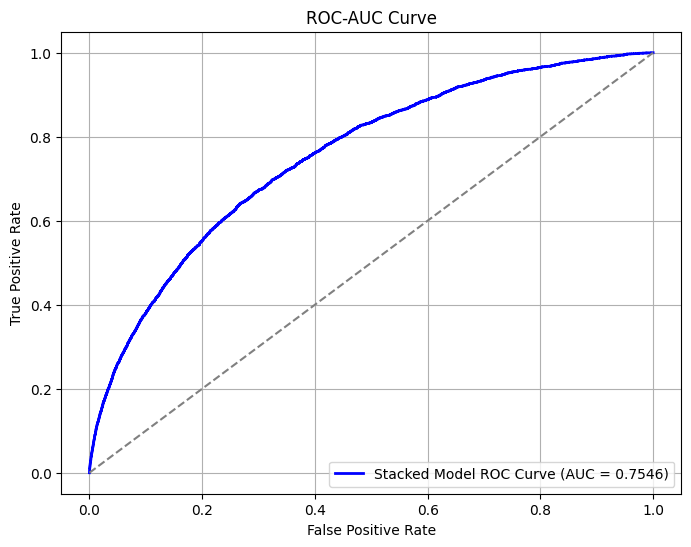

In [71]:
# ROC curve values
fpr, tpr, thresholds = roc_curve(y_valid, stacked_valid)

# Plot ROC-AUC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    color='blue',
    linewidth=2,
    label=f'Stacked Model ROC Curve (AUC = {stack_auc:.4f})'
)

# Random baseline
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Formatting
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

In [72]:
valid_preds = (stacked_valid >= 0.5).astype(int)

print(classification_report(y_valid, valid_preds))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     42403
           1       0.88      0.00      0.00      3724

    accuracy                           0.92     46127
   macro avg       0.90      0.50      0.48     46127
weighted avg       0.92      0.92      0.88     46127

